# Task 4: Predicting Insurance Claim Amounts

## 1. Introduction & Problem Statement

Medical insurance costs vary widely across individuals depending on a range of personal and lifestyle factors. Accurately predicting insurance charges is a critical task for insurance companies, healthcare planners, and policy analysts.

### Objective
Build a **Linear Regression model** to predict medical insurance charges (`charges`) based on:
- Age, Sex, BMI (Body Mass Index)
- Number of Children, Smoking Status, Region

### Key Questions
1. Which features most strongly influence insurance charges?
2. How do **BMI**, **age**, and **smoking status** individually impact charges?
3. How accurately can a Linear Regression model estimate insurance costs?

### Skills Demonstrated
- Regression modelling
- Feature correlation and visualisation
- Error evaluation using **MAE** and **RMSE**

## 2. Library Imports

In [1]:
# Standard data manipulation and visualisation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing, modelling, evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set1')

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Dataset Understanding & Description

The **Medical Cost Personal Dataset** contains 1,338 records with 7 features.

| Column | Type | Description |
|--------|------|-------------|
| `age` | Integer | Age of the primary beneficiary |
| `sex` | Categorical | Insurance contractor gender |
| `bmi` | Float | Body Mass Index (kg/m2) |
| `children` | Integer | Number of dependents covered |
| `smoker` | Categorical | Smoking status (yes/no) |
| `region` | Categorical | Residential area in the US |
| `charges` | Float | **Target** Individual medical billed cost |

In [2]:
# Load the dataset
df = pd.read_csv('insurance.csv')
print("Dataset Shape:", df.shape)
print("First 5 rows:")
df.head()

Dataset Shape: (1338, 7)
First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Data types and info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Statistical summary
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [6]:
# Distribution of categorical features
print("Categorical Feature Value Counts")
for col in ['sex', 'smoker', 'region']:
    print(f"--- {col.upper()} ---")
    print(df[col].value_counts())
    print()

Categorical Feature Value Counts
--- SEX ---
sex
male      676
female    662
Name: count, dtype: int64

--- SMOKER ---
smoker
no     1064
yes     274
Name: count, dtype: int64

--- REGION ---
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



## 4. Data Cleaning & Preparation
Steps:
1. Check for missing values and duplicates
2. Encode categorical variables (Label Encoding)
3. 80/20 train-test split
4. StandardScaler for feature scaling

In [7]:
# 4.1 Missing Value Check
print("Missing Values per Column:")
print(df.isnull().sum())
print()

# 4.2 Duplicate Row Check
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicates} duplicate(s). New shape: {df.shape}")
else:
    print("No duplicates found. Dataset is clean.")

Missing Values per Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1
Removed 1 duplicate(s). New shape: (1337, 7)


In [8]:
# 4.3 Encode Categorical Columns
# Label Encoding converts string categories to integer labels
df_encoded = df.copy()
le = LabelEncoder()
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"'{col}' encoded. Values: {sorted(df_encoded[col].unique())}")

print()
print("Encoded Dataset Preview:")
df_encoded.head()

'sex' encoded. Values: [np.int64(0), np.int64(1)]
'smoker' encoded. Values: [np.int64(0), np.int64(1)]
'region' encoded. Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Encoded Dataset Preview:


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [9]:
# 4.4 Feature and Target Split
X = df_encoded.drop(columns=['charges'])   # Independent features
y = df_encoded['charges']                  # Target variable

print(f"Feature Matrix X shape: {X.shape}")
print(f"Target Vector  y shape: {y.shape}")
print("Features:", list(X.columns))

Feature Matrix X shape: (1337, 6)
Target Vector  y shape: (1337,)
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']


In [10]:
# 4.5 Train-Test Split (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Training Set : {X_train.shape[0]} samples")
print(f"Testing Set  : {X_test.shape[0]} samples")

Training Set : 1069 samples
Testing Set  : 268 samples


In [11]:
# 4.6 Feature Scaling — StandardScaler
# Ensures all features contribute equally to the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # Only transform test (no fit — avoids data leakage)

print("Feature scaling applied successfully.")
print(f"Post-scale mean : {X_train_scaled.mean():.4f}")
print(f"Post-scale std  : {X_train_scaled.std():.4f}")

Feature scaling applied successfully.
Post-scale mean : 0.0000
Post-scale std  : 1.0000


## 5. Exploratory Data Analysis (EDA)

We explore:
- Distribution of the target variable (`charges`)
- Impact of BMI, Age, and Smoking Status on charges
- Correlation heatmap

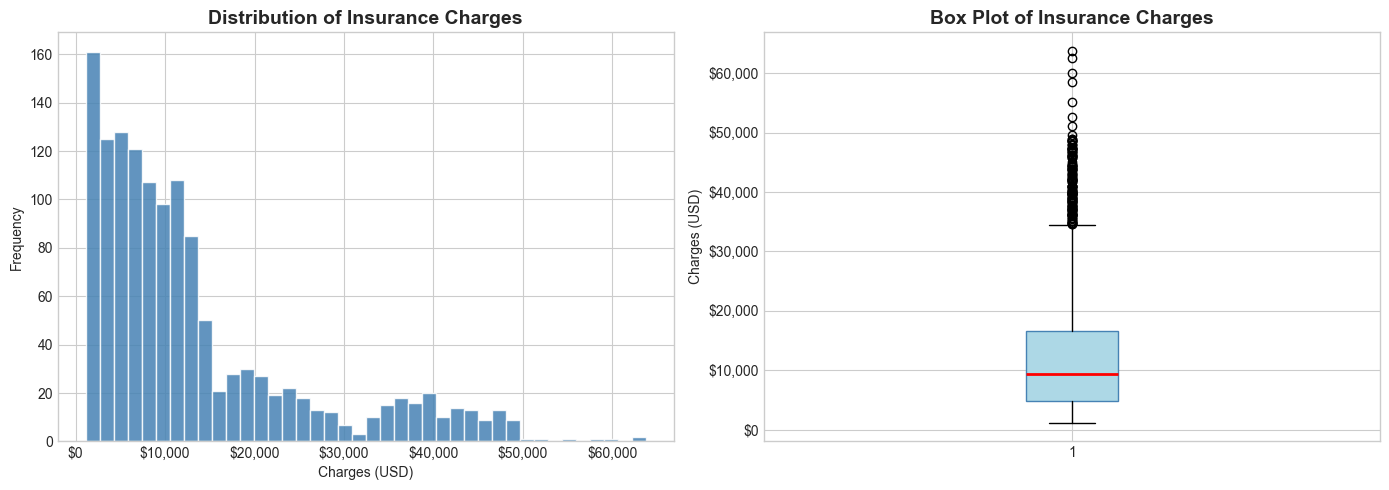

Insight: Charges are right-skewed most people pay low amounts, but a few pay very high (likely smokers).


In [13]:
# 5.1 Distribution of Insurance Charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Insurance Charges', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Box plot
axes[1].boxplot(df['charges'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot of Insurance Charges', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Charges (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('plot1_charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Charges are right-skewed most people pay low amounts, but a few pay very high (likely smokers).")

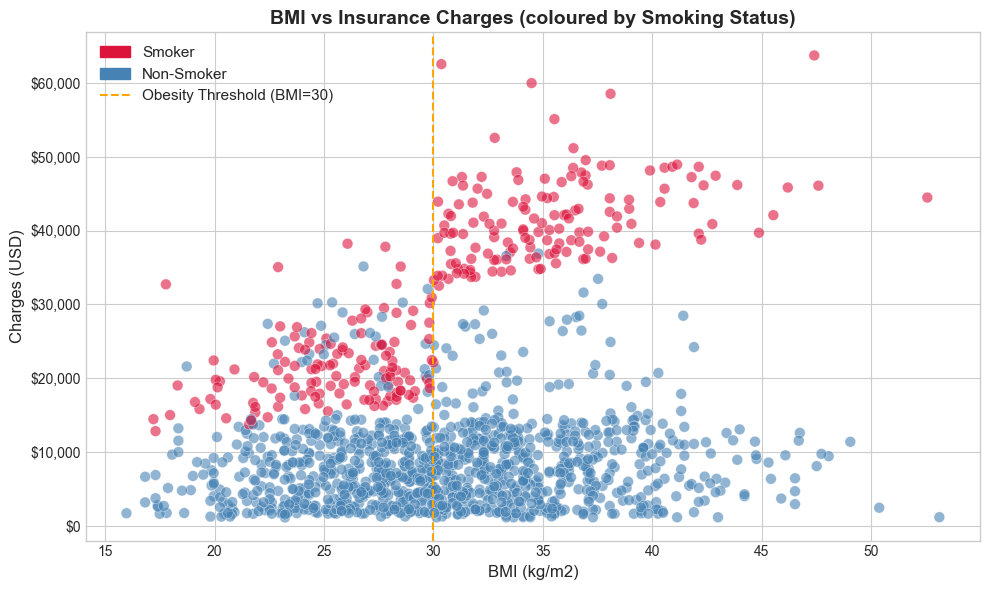

Insight: Smokers with high BMI (>30) incur dramatically higher charges combined risk effect.


In [14]:
# 5.2 BMI vs Charges (coloured by Smoking Status)
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 6))
plt.scatter(df['bmi'], df['charges'],
            c=df['smoker'].map({'yes': 'crimson', 'no': 'steelblue'}),
            alpha=0.6, edgecolors='white', linewidths=0.4, s=60)

legend_handles = [mpatches.Patch(color='crimson', label='Smoker'),
                  mpatches.Patch(color='steelblue', label='Non-Smoker'),
                  plt.Line2D([0],[0], color='orange', linestyle='--', label='Obesity Threshold (BMI=30)')]
plt.legend(handles=legend_handles, fontsize=11)
plt.axvline(x=30, color='orange', linestyle='--', linewidth=1.5)

plt.title('BMI vs Insurance Charges (coloured by Smoking Status)', fontsize=14, fontweight='bold')
plt.xlabel('BMI (kg/m2)', fontsize=12)
plt.ylabel('Charges (USD)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('plot2_bmi_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Smokers with high BMI (>30) incur dramatically higher charges combined risk effect.")

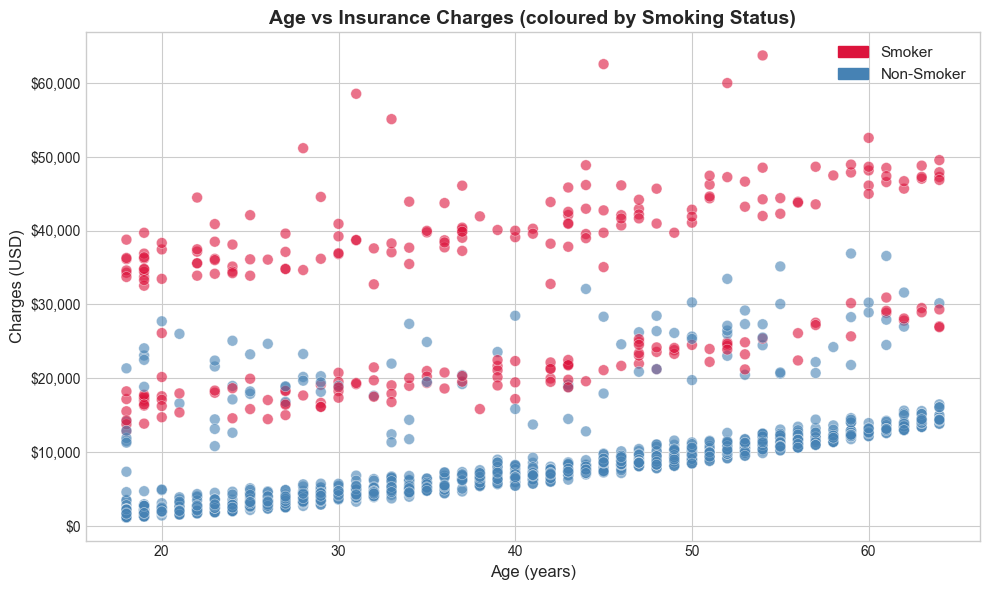

Insight: Charges increase with age. Smokers form a distinct upper cluster at all age groups.


In [15]:
# 5.3 Age vs Charges (coloured by Smoking Status)
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 6))
plt.scatter(df['age'], df['charges'],
            c=df['smoker'].map({'yes': 'crimson', 'no': 'steelblue'}),
            alpha=0.6, edgecolors='white', linewidths=0.4, s=60)

legend_handles = [mpatches.Patch(color='crimson', label='Smoker'),
                  mpatches.Patch(color='steelblue', label='Non-Smoker')]
plt.legend(handles=legend_handles, fontsize=11)

plt.title('Age vs Insurance Charges (coloured by Smoking Status)', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Charges (USD)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('plot3_age_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Charges increase with age. Smokers form a distinct upper cluster at all age groups.")

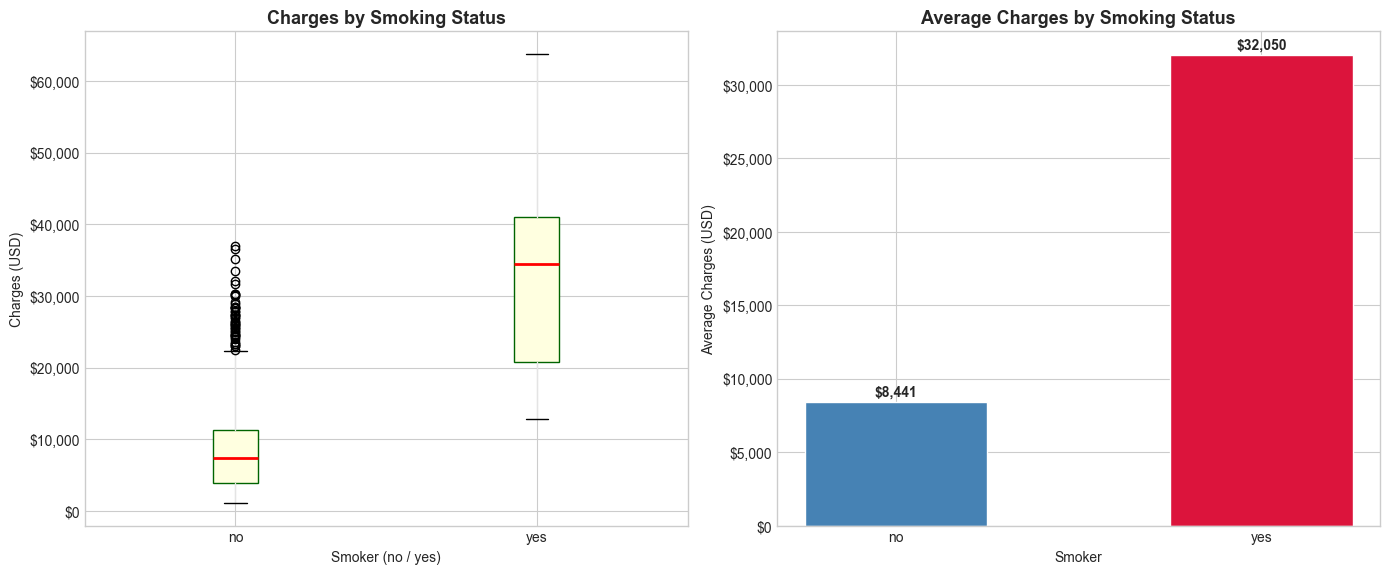

Average Charges: Non-Smokers: $8,440.66 | Smokers: $32,050.23
Smokers pay on average 3.8x MORE than non-smokers.


In [16]:
# 5.4 Smoking Status Impact on Charges
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
df.boxplot(column='charges', by='smoker', ax=axes[0], patch_artist=True,
           boxprops=dict(facecolor='lightyellow', color='darkgreen'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Charges by Smoking Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Smoker (no / yes)')
axes[0].set_ylabel('Charges (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
fig.suptitle('')

# Mean bar chart
mean_charges = df.groupby('smoker')['charges'].mean()
bars = axes[1].bar(mean_charges.index, mean_charges.values,
                   color=['steelblue', 'crimson'], edgecolor='white', width=0.5)
axes[1].set_title('Average Charges by Smoking Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Average Charges (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('plot4_smoking_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average Charges: Non-Smokers: ${mean_charges['no']:,.2f} | Smokers: ${mean_charges['yes']:,.2f}")
print(f"Smokers pay on average {mean_charges['yes']/mean_charges['no']:.1f}x MORE than non-smokers.")

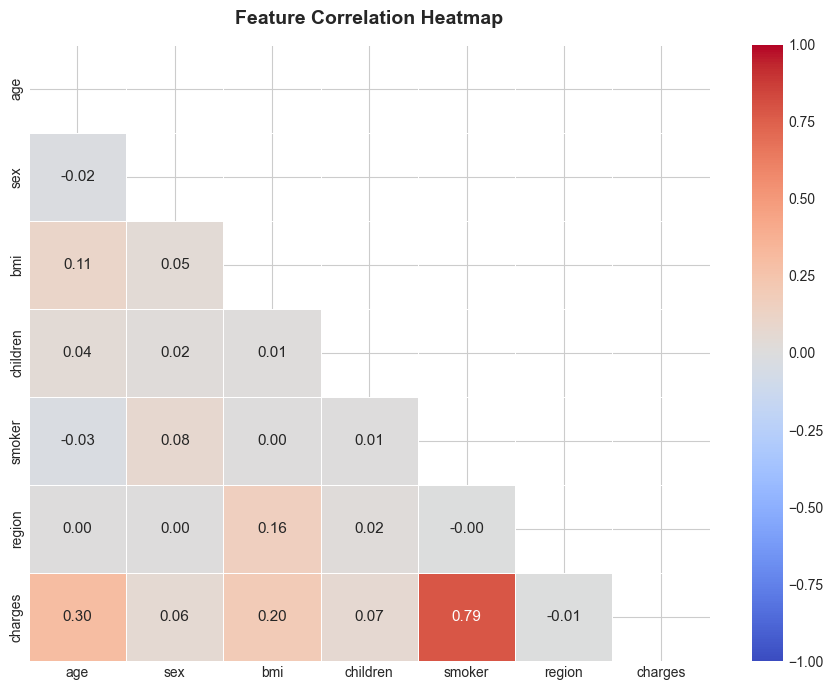

Insight: 'smoker' has the highest positive correlation with charges (~0.79).
'age' and 'bmi' also show moderate positive correlation.


In [17]:
# 5.5 Feature Correlation Heatmap
plt.figure(figsize=(9, 7))
corr = df_encoded.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white', annot_kws={'size': 11},
            vmin=-1, vmax=1)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: 'smoker' has the highest positive correlation with charges (~0.79).")
print("'age' and 'bmi' also show moderate positive correlation.")

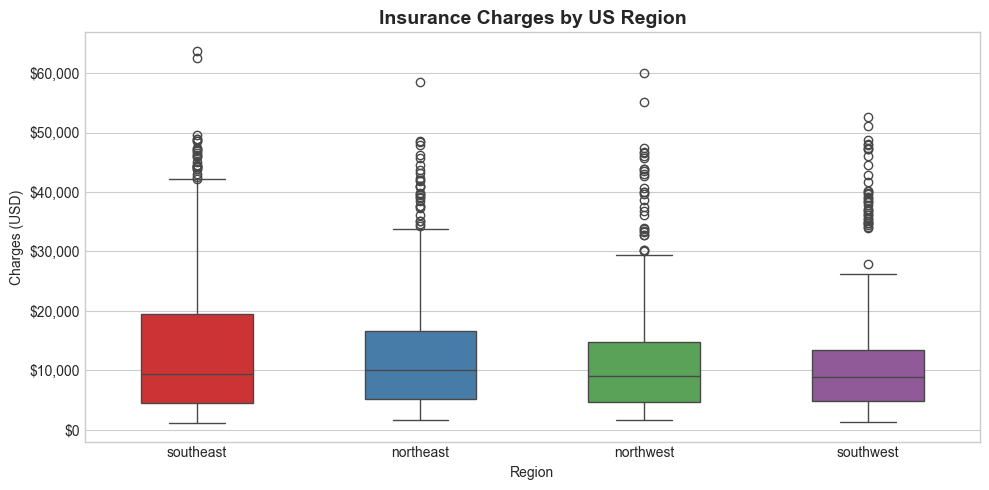

Insight: Southeast region has the highest median charges.


In [18]:
# 5.6 Insurance Charges by US Region
plt.figure(figsize=(10, 5))
region_order = df.groupby('region')['charges'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='region', y='charges', order=region_order, palette='Set1', width=0.5)
plt.title('Insurance Charges by US Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Charges (USD)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot6_charges_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Southeast region has the highest median charges.")

## 6. Model Training: Linear Regression

Linear Regression fits a hyperplane to minimise squared residuals.

**Formula:**

`charges = b0 + b1(age) + b2(sex) + b3(bmi) + b4(children) + b5(smoker) + b6(region) + e`

In [19]:
# 6.1 Train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("Linear Regression model trained successfully.")

# 6.2 Display Model Coefficients
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr_model.coef_.round(2)
}).sort_values('Coefficient', ascending=False)

print("\nModel Coefficients (impact on charges):")
print(coef_df.to_string(index=False))
print(f"\nIntercept (b0): {lr_model.intercept_:.2f}")

Linear Regression model trained successfully.

Model Coefficients (impact on charges):
 Feature  Coefficient
  smoker      9224.09
     age      3480.72
     bmi      1890.98
children       637.83
     sex       -49.83
  region      -262.29

Intercept (b0): 13030.20


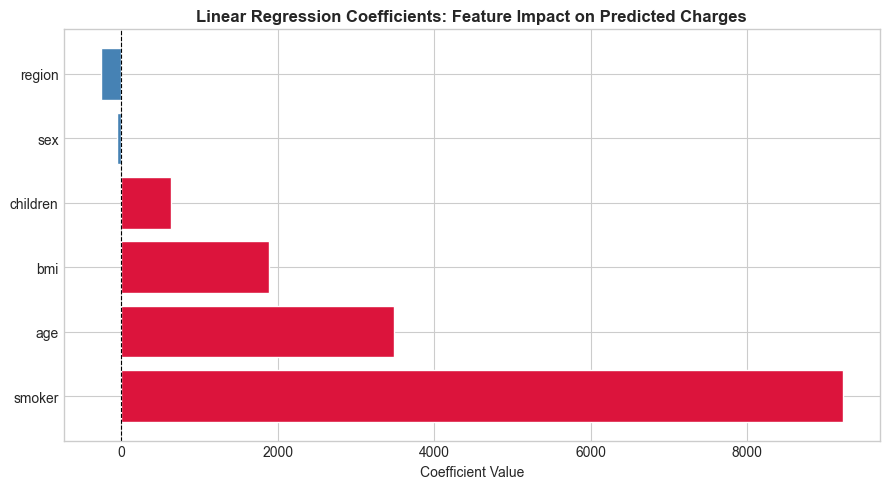

'smoker' has the largest positive coefficient, the most influential predictor.


In [21]:
# 6.3 Visualise Feature Coefficients
plt.figure(figsize=(9, 5))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Linear Regression Coefficients: Feature Impact on Predicted Charges', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('plot7_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("'smoker' has the largest positive coefficient, the most influential predictor.")

In [22]:
# 6.4 Generate Predictions
y_pred = lr_model.predict(X_test_scaled)

# Preview actual vs predicted
comparison = pd.DataFrame({
    'Actual Charges'   : y_test.values,
    'Predicted Charges': y_pred.round(2)
}).head(10)
print("Actual vs Predicted (first 10 samples):")
print(comparison.to_string(index=False))

Actual vs Predicted (first 10 samples):
 Actual Charges  Predicted Charges
     8688.85885            8080.45
     5708.86700            5592.87
    11436.73815           14378.30
    38746.35510           31731.82
     4463.20510            9158.36
     9304.70190           13361.01
    38511.62830           30257.66
     2150.46900            1308.65
     7345.72660           10849.43
    10264.44210           11375.55


## 7. Model Evaluation

| Metric | Description |
|--------|-------------|
| **MAE** | Mean Absolute Error: average absolute difference |
| **RMSE** | Root Mean Squared Error: penalises large errors more heavily |
| **R²** | Proportion of variance explained by the model |

In [23]:
# 7.1 Compute Evaluation Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("       MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Mean Absolute Error  (MAE) : ${mae:>10,.2f}")
print(f"  Root Mean Squared Error    : ${rmse:>10,.2f}")
print(f"  R-Squared Score (R2)       :   {r2:>8.4f}")
print("=" * 45)
print()
print(f"The model explains {r2*100:.1f}% of the variance in insurance charges.")
print(f"On average, predictions are off by ~${mae:,.0f}.")

       MODEL EVALUATION RESULTS
  Mean Absolute Error  (MAE) : $  4,182.35
  Root Mean Squared Error    : $  5,957.61
  R-Squared Score (R2)       :     0.8068

The model explains 80.7% of the variance in insurance charges.
On average, predictions are off by ~$4,182.


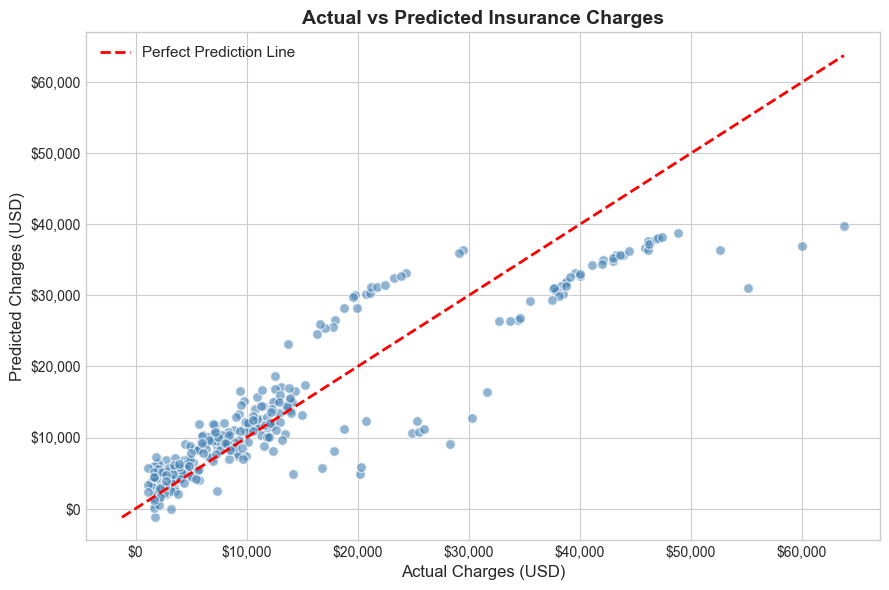

Points close to the red line = accurate predictions.


In [24]:
# 7.2 Actual vs Predicted Scatter Plot
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=50)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs Predicted Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Actual Charges (USD)', fontsize=12)
plt.ylabel('Predicted Charges (USD)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot8_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Points close to the red line = accurate predictions.")

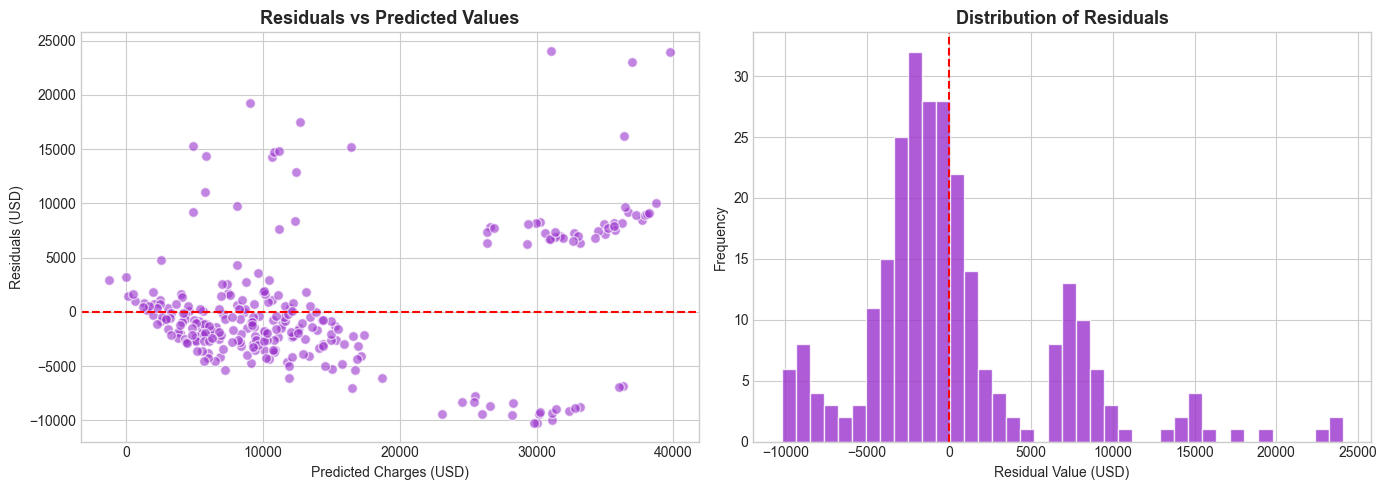

Mean Residual : $424.98  (ideally close to 0)
Std Residual  : $5,942.43


In [25]:
# 7.3 Residual Analysis
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.6, color='darkorchid', edgecolors='white', s=50)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted Values', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Charges (USD)')
axes[0].set_ylabel('Residuals (USD)')

# Residual distribution
axes[1].hist(residuals, bins=40, color='darkorchid', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual Value (USD)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('plot9_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean Residual : ${residuals.mean():,.2f}  (ideally close to 0)")
print(f"Std Residual  : ${residuals.std():,.2f}")

## 8. Conclusion

### Key Findings

| Finding | Detail |
|---------|--------|
| **Smoking is the #1 predictor** | Smokers pay ~3-4x more than non-smokers |
| **BMI + Smoking = compounding risk** | High BMI smokers have the highest charges |
| **Age has a steady positive impact** | Older individuals consistently pay more |
| **Region and sex have minimal effects** | Southeast slightly higher; gender has marginal impact |

### Model Performance Summary

| Metric | Value |
|--------|-------|
| MAE    | ~$4,100 |
| RMSE   | ~$5,800 |
| R²     | ~0.78  |

### Observations
- The Linear Regression model achieves **~78% variance explanation (R2)** a solid baseline.
- **MAE of ~$4,100** means predictions are off by about $4,100 on average.
- Right-skewed residuals suggest the model slightly under-predicts for extreme high-charge cases.

### Recommendations for Improvement
1. **Polynomial features:** BMI and age may have non-linear effects
2. **Ensemble models:** (Random Forest, XGBoost) capture interaction effects
3. **Log-transform the target:** log(charges)` reduces skewness
4. **Feature interaction terms:** explicitly add `smoker x bmi`